In [1]:
using Revise
using Printf
using LinearAlgebra
using PyPlot
using FFTW
using MultiModeNoise

[ Info: Precompiling MultiModeNoise [b336628f-8386-4303-a33d-f2bdce4c2a6e]


This notebook explains how to compute Fig. 4d-fof the main manuscript. Due to resource demand of the simulations when working with the parameters used for the paper, the set-up of the calculation need to be adapted for the cluster at hand.

In [2]:
# Here we define the necessary parameters for the simulation
# Wavelength [m]
λ0 = 1550e-9
# Number of modes
M = 3
# Number of grid points for the temporal/spectral information
Nt = 2^10
# Width of the time window considered in the pulsed simulations [ps]
time_window = 5 # ps
# Order of expansion in the dispersion operator, i.e., β_order + 1 = number of terms in D(w)
β_order = 2

2

In [3]:
# Put the simulation parameters and derived quantities into a dictionary to pass to other functions
sim = MultiModeNoise.get_disp_sim_params(λ0, M, Nt, time_window, β_order);

In [4]:
# Here we define the parameters of the graded index (GRIN) fiber we are considering in this example (Thorlabs GIF625)
# Length of the fiber [m]
L_fiber = 1 
# Radius of the fiber [μm]
radius = 62.5/2 
# Numerical aperture of the fiber's core
core_NA = 0.275 
# Shape parameter of the GRIN fiber
alpha = 2.08 
# Number of gridpoints in x & y to compute the fiber parameters and 
nx = 200 
# Name and directory of a file in which to store the fiber parameters once computed or from which to load if they have beeen computed already
fiber_fname = @sprintf("../fibers/DispersiveFiber_GRIN_r=%.2f_M=%d_λ0=%.2fum_Nt=%d_time_window=%.2fps_nx=%d_Nbeta=%d.npz", radius, M, 1e6*λ0, 
    Nt, time_window, nx, β_order+1)

"../fibers/DispersiveFiber_GRIN_r=31.25_M=3_λ0=1.55um_Nt=1024_time_window=5.00ps_nx=200_Nbeta=3.npz"

In [5]:
# Here we compute/load the fiber properties (longitudinal phase evolution and nonlinear coupling) from the fiber parameters 
# and store them in a dictionary to pass to other functions
fiber = MultiModeNoise.get_disp_fiber_params(L_fiber, radius, core_NA, alpha, nx, sim, fiber_fname);

Load fiber params


In [6]:
# Here we set a fiber parameter that defines at which z-values functions return the field ampltidues
fiber["zsave"] = LinRange(0, L_fiber, 101);

In [7]:
# Define the inital conditions of the modal amplitudes that are sent into the fiber (Randomly chosen here)
# Average (continuous) power [W]
P_cont = 0.25
# Full width half max of the input pulse [s]
pulse_fwhm = 185e-15
# Repetition rate of the laser [Hz], used to convert between average and peak power
pulse_rep_rate = 80.5e6 # Hz
# Shape of the input pulse.
pulse_shape = "sech_sq"

# Modal amplitudes othe input pulse
u0_modes = normalize([0.4, 0.1, 0.0])
println(abs2.(u0_modes))

# Compute the temporal and spectral form of the input pulse for each mode
ut0, uω0 = MultiModeNoise.get_initial_state(u0_modes, P_cont, pulse_fwhm, pulse_rep_rate, pulse_shape, sim);

[0.9411764705882353, 0.058823529411764705, 0.0]


In [8]:
# Solve the z-evolution of the pulse inside the fiber and store the result in a dictionary
sol_disp_mmf = MultiModeNoise.solve_disp_mmf(uω0, fiber, sim);

In [9]:
# Extract the modal ampltiudes in the frequency domain for different z-values
uω_z = sol_disp_mmf["uω_z"];

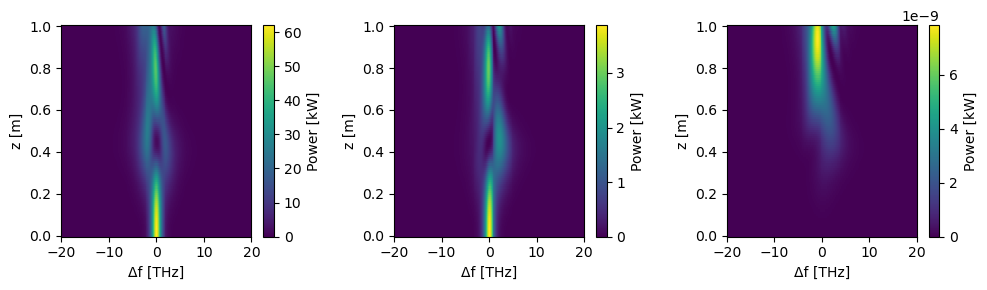

In [10]:
# Plot the z-evolution of the spectrally resolved pulse in each of the considered modes
ZZ, FF = MultiModeNoise.meshgrid(sim["fs"] .- sim["f0"], fiber["zsave"])

fig, axs = subplots(1, 3, figsize=(10,3))
for i in 1:M
    im = axs[i].pcolormesh(ZZ, FF, Nt*abs2.(fftshift(uω_z[:,:,i], 2))/1e3, shading="nearest")
    fig.colorbar(im, ax=axs[i], label="Power [kW]")
    axs[i].set_xlim(-20,20)
    axs[i].set_xlabel("Δf [THz]")
    axs[i].set_ylabel("z [m]")
end
fig.tight_layout()

In [11]:
# Here, we remove any predefined points at which the solver saves the modal amplitudes during the z-evolution. Instead the ODE solving 
# algorithm determines the z-values at which the modal amplitudes are saved such that the field can be accessesd at an arbitrary z-value. 
# We do this because in solving the adjoint ODE to determine sensitivies, we need to know the modal amplitudes at an arbitrary z-value.
fiber["zsave"] = nothing

In [12]:
# Solve the z-evolution of the pulse inside the fiber and store the result in a dictionary
sol_disp_mmf = MultiModeNoise.solve_disp_mmf(uω0, fiber, sim);

In [13]:
# Here, we are interested in computing the intensity noise of a single pixel (here at x=y=5)
XX, YY = MultiModeNoise.meshgrid(fiber["x"], fiber["x"])
ϕ_pix = fiber["ϕ"][argmin(vec((XX .- 5).^2 + (YY .- 5).^2)),:];
# λ(L) for the adjoint simulation
λωL = 2 * ((uω_z[end,:,:] * ϕ_pix) * ϕ_pix');

In [14]:
# Solve the z-evolution for the adjoint field from z=l to z=0
sol_adjoint_disp_mmf = MultiModeNoise.solve_adjoint_disp_mmf(λωL, sol_disp_mmf["ode_sol"], fiber, sim);

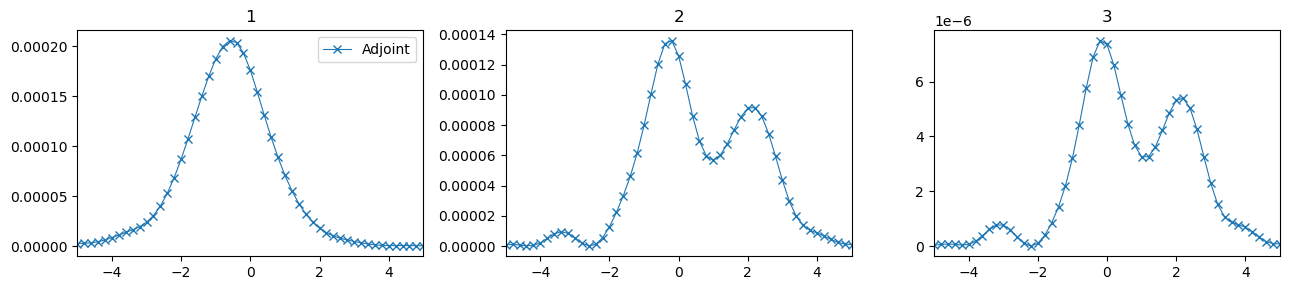

In [15]:
# Spectral plot of λ(0) for all 3 modes
fig, axs = subplots(1, M, figsize=(13,3))
for i in 1:M
    axs[i].set_title(i)
    axs[i].plot((sim["fs"] .- sim["f0"]), abs2.(fftshift(sol_adjoint_disp_mmf(0)[:,i])), "x-", lw=0.8, label="Adjoint")
    axs[i].set_xlim(-5,5)
end
axs[1].legend()
fig.tight_layout()

In [16]:
# Here, we want to compute the full spatial map of the intensity noise at the output facet of the fiber. To this end we need the 
# sensitivies of the time averaged coherences X_kl to implement the formulas from section II.C of the supplementary material.
# in the double loop here each calcualtion is independent from each other, so we parallelized this part on a cluster for the 
# computation of Fig. 4e-f.

∂Xkl∂u = zeros(ComplexF64, M, M, Nt, M)

for k in 1:M
    for l in 1:M
        λωL = 2 * uω_z[end,:,l] * diagm(ones(M))[:,k]'
        sol_adjoint_disp_mmf = MultiModeNoise.solve_adjoint_disp_mmf(λωL, sol_disp_mmf["ode_sol"], fiber, sim)
        ∂Xkl∂u[k,l,:,:] = -0.5*sqrt(sim["ε"]*Nt)*conj.(sol_adjoint_disp_mmf(0))

        print(@sprintf("\r%d/%d, %d/%d", k, M, l, M)); flush(stdout)
    end
end

3/3, 3/3

In [22]:
U = u0_modes
# Spectral distribution of the excess input noise, assumed proportional to the spectral input intensity.
δF_in_ω = abs2.(uω0[:,1]) ./ maximum(abs2.(uω0[:,1])) * (1e3-1)
uωf = uω_z[end,:,:];

In [25]:
# Compute the spatially resolved photon number and photon number variance at the output of the fiber. Here, we assume that we have one 
# single source with excess noise (δF_in_ω) that is split among the various fiber modes.
n, var_n = MultiModeNoise.compute_disp_spatial_n_var_n(uωf, ∂Xkl∂u, δF_in_ω, U, fiber, sim);

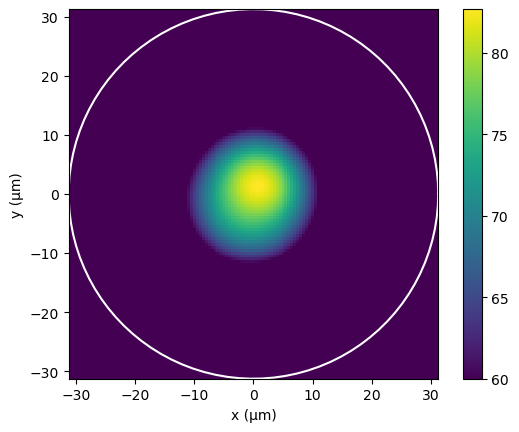

PyObject Text(24.000000000000007, 0.5, 'y (μm)')

In [26]:
# Plot the spatially resolved photon number variance
MultiModeNoise.plot_fiber(fiber["x"], MultiModeNoise.lin_to_dB.(reshape(var_n, (nx, nx))), radius, radius, vmin=60)